# Validation of my Bessetti-Erskine implementation against the 'PyPIC' solver for circular beam pipes

In [ ]:
import sys
import os
import numpy as np
from scipy.constants import e, epsilon_0
import matplotlib.pyplot as plt

import PyPIC.FFT_OpenBoundary_SquareGrid as PIC_FFT
import PyPIC.geom_impact_ellip as ell

current_dir = os.getcwd()
pybe_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, pybe_dir)

import beam_pipe

## Set up grid and chamber

In [ ]:
grid_length = 40
pipe_radius = 100

chamber = ell.ellip_cham_geom_object(x_aper=pipe_radius, y_aper=pipe_radius)  # Circular chamber
Dh = pipe_radius/grid_length

pic_fft = PIC_FFT.FiniteDifferences_ShortleyWeller_SquareGrid(x_aper=pipe_radius, y_aper=pipe_radius, Dh=Dh)
x, y = np.meshgrid(pic_fd.yg, pic_fd.xg)

Start PIC init.:
Finite Differences, Square Grid
PyPIC Version 2.4.5
Mat. assembly 0%
Mat. assembly 5%
Mat. assembly 10%
Mat. assembly 15%
Mat. assembly 20%
Mat. assembly 25%
Mat. assembly 30%
Mat. assembly 35%
Mat. assembly 40%
Mat. assembly 45%
Mat. assembly 50%
Mat. assembly 55%
Mat. assembly 60%
Mat. assembly 65%
Mat. assembly 70%
Mat. assembly 75%
Mat. assembly 80%
Mat. assembly 85%
Mat. assembly 90%
Mat. assembly 95%
Mat. assembly 100%
Using scipy superlu solver...
Done PIC init.
Start PIC init.:
Finite Differences, Shortley-Weller, Square Grid
Using Shortley-Weller boundary approx.
PyPIC Version 2.4.5
Mat. assembly 0%
Mat. assembly 5%
Mat. assembly 10%
Mat. assembly 15%
Mat. assembly 20%
Mat. assembly 25%
Mat. assembly 30%
Mat. assembly 35%
Mat. assembly 40%
Mat. assembly 45%
Mat. assembly 50%
Mat. assembly 55%
Mat. assembly 60%
Mat. assembly 65%
Mat. assembly 70%
Mat. assembly 75%
Mat. assembly 80%
Mat. assembly 85%
Mat. assembly 90%
Mat. assembly 95%
Mat. assembly 100%
Interna

## Solve for specific Gaussian charge distribution
Play with top 4 params!

In [137]:
beam_pos_x = 10
beam_pos_y = 10
sigma_x = 10
sigma_y = 15

A = 1./(2.*np.pi*sigma_x*sigma_y)  # Prefactor
s_squared = (x-beam_pos_x)**2/(sigma_x**2) + (y-beam_pos_y)**2/(sigma_y**2)  # elliptical radius squared
rho_matrix = A*np.exp(-s_squared/2)  # Gaussian in S

pic_fd.solve(rho=rho_matrix)
pic_fd_sw.solve(rho=rho_matrix)

## Evaluate (probe) uniformly within the circle

In [138]:
probes_x = []
probes_y = []
for i in range(grid_length):
    for j in range(grid_length):
        x = (i-(grid_length/2))*2*pipe_radius/grid_length
        y = (j-(grid_length/2))*2*pipe_radius/grid_length
        if x**2+y**2<pipe_radius**2:
            probes_x.append(x)
            probes_y.append(y)
probes_x = np.array(probes_x)
probes_y = np.array(probes_y)

field_x_fd, field_y_fd = pic_fd.gather(probes_x, probes_y)
field_x_fdsw, field_y_fdsw = pic_fd_sw.gather(probes_x, probes_y)

field_x_be, field_y_be = beam_pipe.beam_pipe_gaussian_field(probes_x, probes_y, 
                                                            beam_pos_x, beam_pos_y, 
                                                            sigma_x, sigma_y, pipe_radius)
field_x_be = 1/(4*np.pi*epsilon_0)*field_x_be
field_y_be = 1/(4*np.pi*epsilon_0)*field_y_be

/home/rsimpson/Documents/Degree/MPhys Project/Code/PyBE/beam_pipe.py:46: RuntimeWarning: invalid value encountered in divide
  x_im = pipe_radius**2*x/r2
/home/rsimpson/Documents/Degree/MPhys Project/Code/PyBE/beam_pipe.py:47: RuntimeWarning: invalid value encountered in divide
  y_im = pipe_radius**2*y/r2
/home/rsimpson/Documents/Degree/MPhys Project/Code/PyBE/beam_pipe.py:58: RuntimeWarning: divide by zero encountered in divide
  outside_field = 2/(x-1j*y)  # Field from point charge
/home/rsimpson/Documents/Degree/MPhys Project/Code/PyBE/beam_pipe.py:58: RuntimeWarning: invalid value encountered in divide
  outside_field = 2/(x-1j*y)  # Field from point charge


## Gather probes back into an array

In [139]:
def gather_to_mesh(probes_x, probes_y, data, grid_length):
    arr = np.zeros((grid_length, grid_length))
    for n in range(len(probes_x)):
        i = int(round((grid_length/2) * (probes_x[n]/chamber_radius + 1)))
        j = int(round((grid_length/2) * (probes_y[n]/chamber_radius + 1)))
        arr[i,j]=data[n]
    return arr

field_x_fd_mesh = gather_to_mesh(probes_x, probes_y, field_x_fd, grid_length)
field_y_fd_mesh = gather_to_mesh(probes_x, probes_y, field_y_fd, grid_length)
field_x_fdsw_mesh = gather_to_mesh(probes_x, probes_y, field_x_fdsw, grid_length)
field_y_fdsw_mesh = gather_to_mesh(probes_x, probes_y, field_y_fdsw, grid_length)
field_x_be_mesh = gather_to_mesh(probes_x, probes_y, field_x_be, grid_length)
field_y_be_mesh = gather_to_mesh(probes_x, probes_y, field_y_be, grid_length)

rms_diff_fd = np.sqrt((field_x_fd_mesh - field_x_be_mesh)**2 + 
                  (field_y_fd_mesh - field_y_be_mesh)**2)
rms_diff_fdsw = np.sqrt((field_x_fdsw_mesh - field_x_be_mesh)**2 + 
                    (field_y_fdsw_mesh - field_y_be_mesh)**2)

# Normalize by reference field magnitude (with safety)
field_mag_fd = np.sqrt(field_x_fd_mesh**2 + field_y_fd_mesh**2)
field_mag_fdsw = np.sqrt(field_x_fdsw_mesh**2 + field_y_fdsw_mesh**2)

relative_error_fd = rms_diff_fd / field_mag_fd
relative_error_fdsw = rms_diff_fdsw / field_mag_fdsw

/tmp/ipykernel_125301/2794427018.py:25: RuntimeWarning: invalid value encountered in divide
  relative_error_fd = rms_diff_fd / field_mag_fd
/tmp/ipykernel_125301/2794427018.py:26: RuntimeWarning: invalid value encountered in divide
  relative_error_fdsw = rms_diff_fdsw / field_mag_fdsw


## Plot

(20, 20)


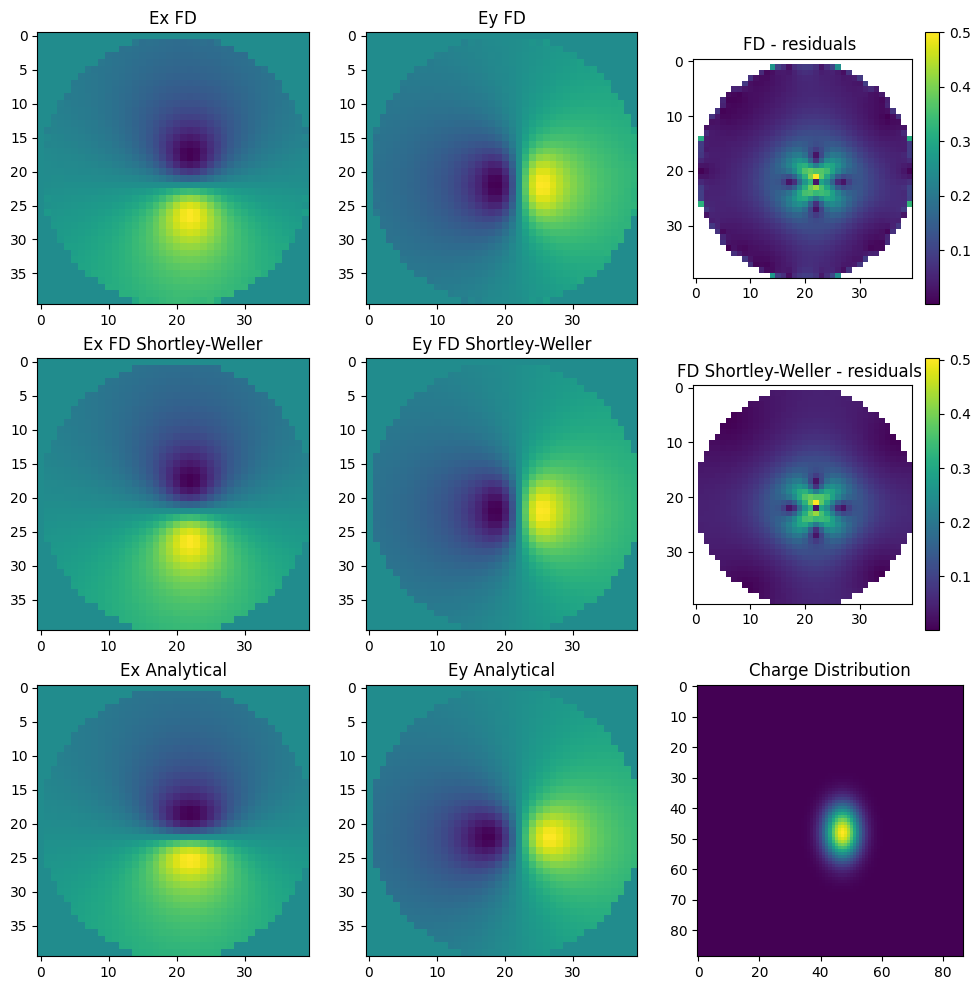

In [140]:
print(np.shape(field_mag_fd_mesh))

fig,axs = plt.subplots(3,3, figsize=(12, 12))
axs[0][0].imshow(field_x_fd_mesh)
axs[0][0].set_title('Ex FD')
axs[0][1].imshow(field_y_fd_mesh)
axs[0][1].set_title('Ey FD')
im1 = axs[0][2].imshow(relative_error_fd)
axs[0][2].set_title('FD - residuals ')
fig.colorbar(im1, ax=axs[0][2])

axs[1][0].imshow(field_x_fdsw_mesh)
axs[1][0].set_title('Ex FD Shortley-Weller')
axs[1][1].imshow(field_y_fdsw_mesh)
axs[1][1].set_title('Ey FD Shortley-Weller')
im2 = axs[1][2].imshow(relative_error_fdsw)
axs[1][2].set_title('FD Shortley-Weller - residuals ')
fig.colorbar(im2, ax=axs[1][2])

axs[2][0].imshow(field_x_be_mesh)
axs[2][0].set_title('Ex Analytical')
axs[2][1].imshow(field_y_be_mesh)
axs[2][1].set_title('Ey Analytical')
axs[2][2].imshow(rho_matrix)
axs[2][2].set_title('Charge Distribution')
plt.show()

## $R^2$

In [141]:
from sklearn.metrics import r2_score

r2_fd_x = r2_score(field_x_be_mesh.flatten(), field_x_fd_mesh.flatten())
r2_fd_y = r2_score(field_y_be_mesh.flatten(), field_y_fd_mesh.flatten())
r2_fd = np.mean((r2_fd_x, r2_fd_y))

r2_fdsw_x = r2_score(field_x_be_mesh.flatten(), field_x_fdsw_mesh.flatten())
r2_fdsw_y = r2_score(field_y_be_mesh.flatten(), field_y_fdsw_mesh.flatten())
r2_fdsw = np.mean((r2_fdsw_x, r2_fdsw_y))

print(r2_fd)
print(r2_fdsw)

0.9763301220226919
0.9765450204562272
